# Logistic Model

## Importaciones

In [1]:
import time
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.linear_model import LogisticRegression

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold

In [6]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

## Cargado de datos

In [7]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 15), (42539, 15), (170152, 1), (42539, 1))

In [9]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

## Funciones usadas

In [10]:
from funciones import *

## modelo logistico benchmark 

In [11]:
pipe_logit = crear_pipeline(LogisticRegression(max_iter=1000,random_state=0,multi_class='ovr',solver='saga',penalty='elasticnet',l1_ratio=0.5), tipo="normal")

In [12]:
start = time.time()
model_pipe=pipe_logit.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.10 minutos


se evalua el modelo benchmark para revisar sus metricas 

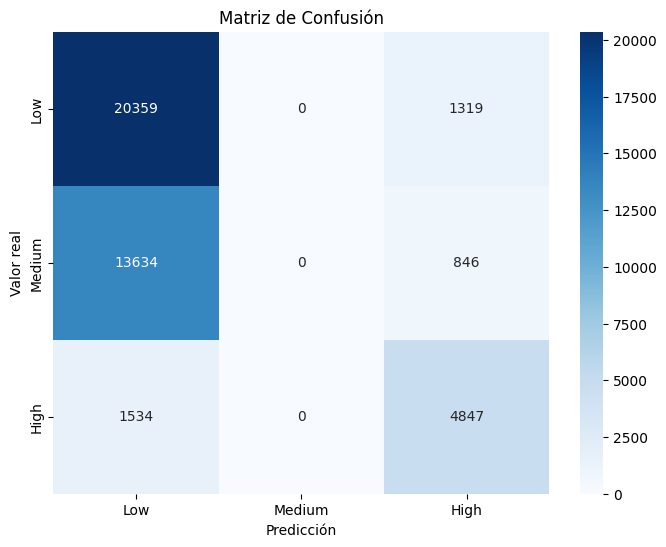


Classification Report:

              precision    recall  f1-score   support

         Low       0.57      0.94      0.71     21678
      Medium       0.00      0.00      0.00     14480
        High       0.69      0.76      0.72      6381

    accuracy                           0.59     42539
   macro avg       0.42      0.57      0.48     42539
weighted avg       0.40      0.59      0.47     42539



{'Accuracy': 0.5925386116269776,
 'Precision (macro)': 0.42143356464092907,
 'Recall (macro)': 0.566251237517668,
 'F1-score (macro)': 0.47853395779435487,
 'ROC-AUC': np.float64(0.7338948325316103)}

In [13]:
evaluar_modelo(model_pipe,X_test,y_test)

Podemos observar que en la version normal del modelode logistic el modelo tiene buenos scores en Low y High sobre todo en la metrica de recall pero no detecta medium de ninguna manera, no hay scores de medium, lo que tambien se observa en su matriz de confusion ya que ningun elemento de medium fue predicho correctamente siendo la mayoria predichos como low erroneamente. esto se puede deber al desbalanceo del modelo

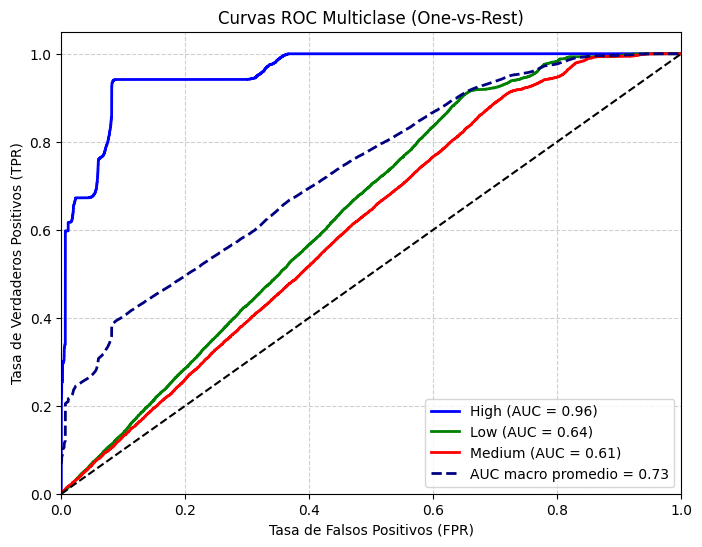


===== AUC por clase =====
High: 0.9579
Low: 0.6377
Medium: 0.6061
AUC macro promedio: 0.7339


({0: np.float64(0.9579406274499217),
  1: np.float64(0.6376857765934167),
  2: np.float64(0.6060580935514924)},
 np.float64(0.733914251780824))

In [14]:
plot_roc_multiclass(model_pipe,X_test,y_test)

El modelo muestra un excelente desempeño para la clase “High” (AUC = 0.9579), lo que indica una alta capacidad para identificar correctamente los casos de alto riesgo.
Sin embargo, las clases “Low” (0.6377) y “Medium” (0.6061) presentan un rendimiento moderado a bajo, reflejando cierta dificultad para distinguir entre niveles de riesgo menos severos.

El AUC macro promedio (0.733) confirma un rendimiento global aceptable, aunque con margen de mejora en la diferenciación de las clases minoritarias.

Podemos observar que los AUC de las 3 clases en el modelo logistico normal benchmark tiene High es la que tiene mejor capacidad discriminatoria entre clases a diferencia del resto, con Low y medium tienen mas dificultades para separar las clases, con scores mas bajos de 0.64 y 0.61, por lo que se debe tomar en cuenta para mas adelante

## balanceo

Se aplico el balanceo mediante SMOTE y ADASYN para determinar si mejora el modelo

### SMOTE

In [15]:
pipe_logit_bal = crear_pipeline(LogisticRegression(max_iter=1000,random_state=0,multi_class='ovr',solver='saga',penalty='elasticnet',l1_ratio=0.5), tipo="balanceo_smote")

In [16]:
start = time.time()
model_bal=pipe_logit_bal.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.23 minutos


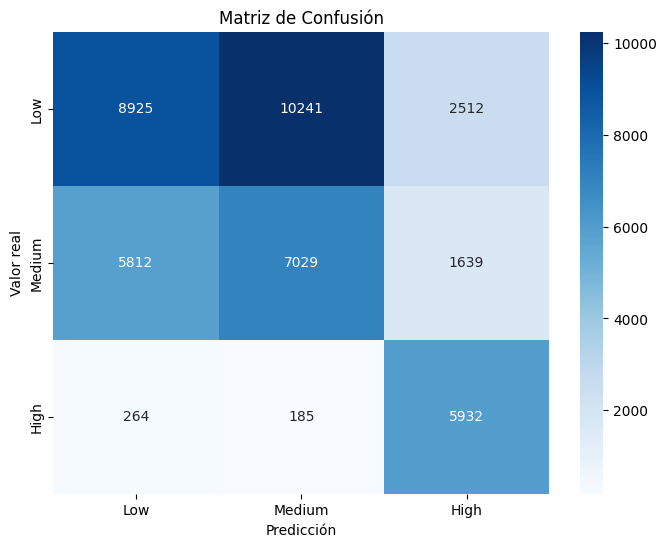


Classification Report:

              precision    recall  f1-score   support

         Low       0.59      0.41      0.49     21678
      Medium       0.40      0.49      0.44     14480
        High       0.59      0.93      0.72      6381

    accuracy                           0.51     42539
   macro avg       0.53      0.61      0.55     42539
weighted avg       0.53      0.51      0.51     42539



{'Accuracy': 0.5144925832765227,
 'Precision (macro)': 0.528656647782051,
 'Recall (macro)': 0.6089235841271364,
 'F1-score (macro)': 0.5491545618225436,
 'ROC-AUC': np.float64(0.7354882101440374)}

In [17]:
evaluar_modelo(model_bal,X_test,y_test)

Podemos observar que ahora que el modelo no esta sesgado hacia Low su recall bajo pero el modelo generaliza de mejor manera, el modelo tambien ahora reconoce casi la mitad de los mediums lo cual es una mejora notable, ademas el recall de high se mantiene fuerte y hasta aumenta pero perdio algo de precision

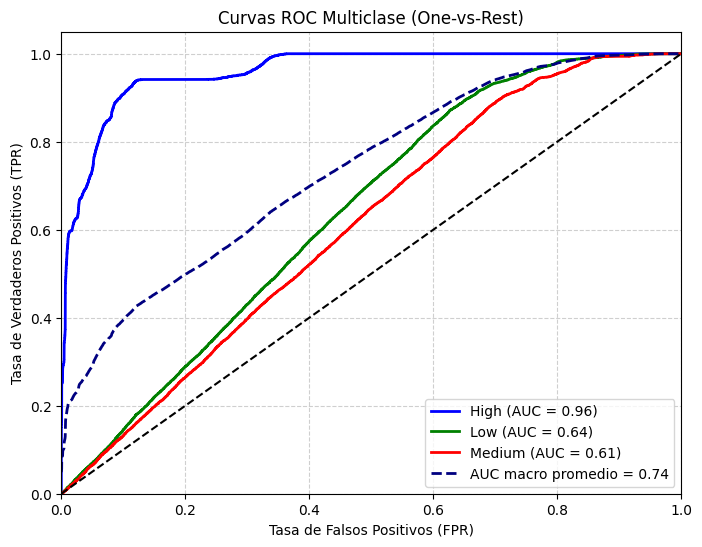


===== AUC por clase =====
High: 0.9593
Low: 0.6394
Medium: 0.6078
AUC macro promedio: 0.7355


({0: np.float64(0.9593286439769096),
  1: np.float64(0.6393591856375099),
  2: np.float64(0.6077768008176929)},
 np.float64(0.7355068742926003))

In [18]:
plot_roc_multiclass(model_bal,X_test,y_test)

Podemos observar que los AUC de cada modelo no cambiaron demasiado a comparacion del modelo anterior, teniendo valores relativamente similares 

### ADASYN

Se prueba con ADASYN para revisar si generan mejores resultados

In [19]:
pipe_logit_ads = crear_pipeline(LogisticRegression(max_iter=1000,random_state=0,multi_class='ovr',solver='saga',penalty='elasticnet',l1_ratio=0.5), tipo="balanceo_adasyn")

In [20]:
start = time.time()
model_ads=pipe_logit_ads.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.36 minutos


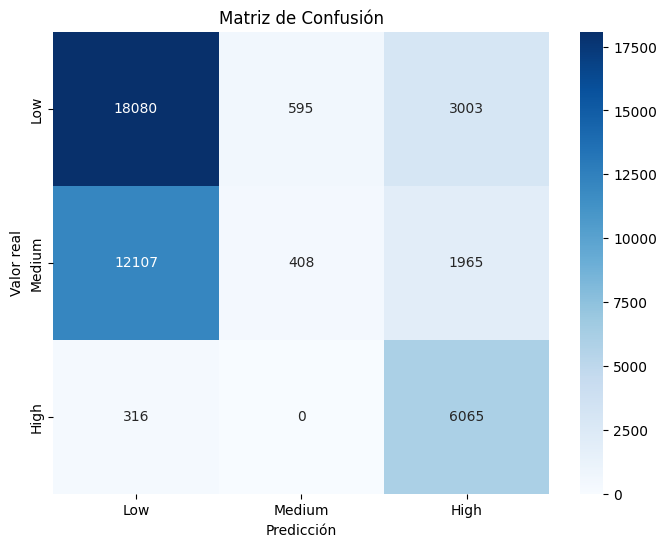


Classification Report:

              precision    recall  f1-score   support

         Low       0.59      0.83      0.69     21678
      Medium       0.41      0.03      0.05     14480
        High       0.55      0.95      0.70      6381

    accuracy                           0.58     42539
   macro avg       0.52      0.60      0.48     42539
weighted avg       0.52      0.58      0.48     42539



{'Accuracy': 0.5771879921953972,
 'Precision (macro)': 0.5164075793252094,
 'Recall (macro)': 0.6042266853908326,
 'F1-score (macro)': 0.4807471612776572,
 'ROC-AUC': np.float64(0.7363009719484391)}

In [21]:
evaluar_modelo(model_ads,X_test,y_test)

Podemos observar que si bien el modelo se beneficio nuevamente de Low y High se dejo por de lado a medium en cuanto a recall, casi nunca se detecta dicha clase por lo que ADASYN reforzo la deteccion de High pero dejo de lado a medium en cuanto a recall se refiere, por lo que a comparacion de SMOTE al realizar el balanceo no pudo mejorar la situacion 

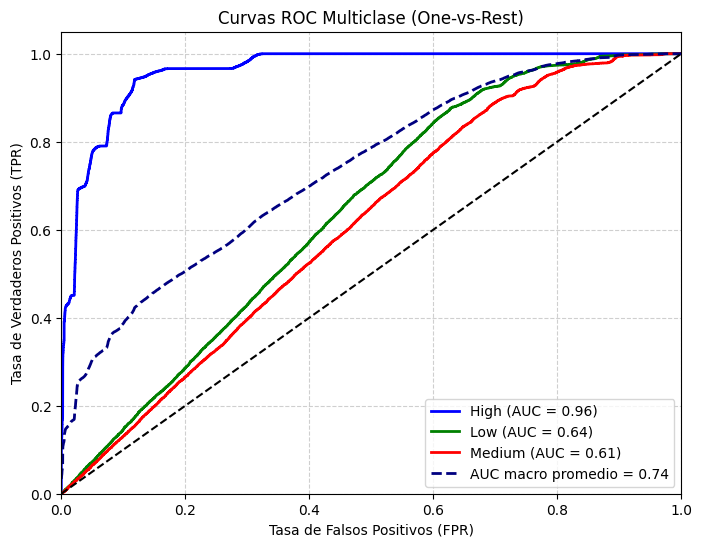


===== AUC por clase =====
High: 0.9610
Low: 0.6397
Medium: 0.6082
AUC macro promedio: 0.7363


({0: np.float64(0.9610232646685806),
  1: np.float64(0.6396961353451595),
  2: np.float64(0.6081835158315774)},
 np.float64(0.7363197768739524))

In [22]:
plot_roc_multiclass(model_ads,X_test,y_test)

El modelo muestra un excelente desempeño para la clase “High” (AUC = 0.9610), lo que indica una alta capacidad para identificar correctamente los casos de alto riesgo.
Sin embargo, las clases “Low” (0.6397) y “Medium” (0.6082) presentan un rendimiento moderado a bajo, reflejando cierta dificultad para distinguir entre niveles de riesgo menos severos.

El AUC macro promedio (0.736) confirma un rendimiento global aceptable, aunque con margen de mejora en la diferenciación de las clases minoritarias.

### Class weight balanced

In [23]:
pipe_logit_cw = crear_pipeline(LogisticRegression(max_iter=1000,random_state=0,multi_class='ovr',class_weight='balanced',penalty='elasticnet',l1_ratio=0.5,solver='saga'), tipo="normal")

In [24]:
start = time.time()
model_cw=pipe_logit_cw.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.09 minutos


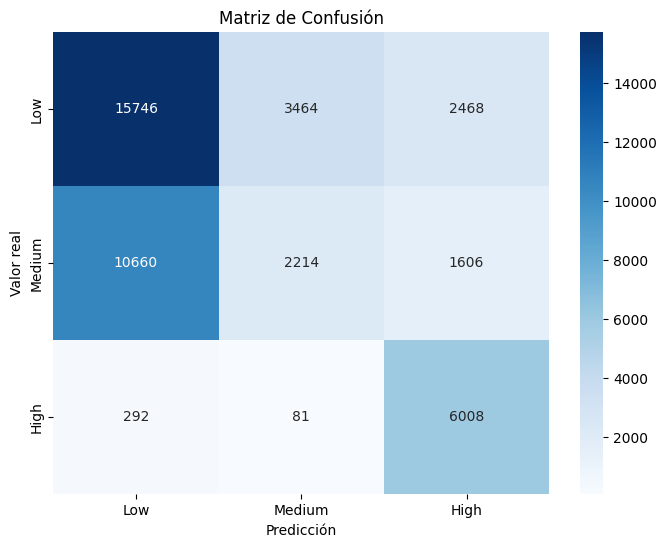


Classification Report:

              precision    recall  f1-score   support

         Low       0.59      0.73      0.65     21678
      Medium       0.38      0.15      0.22     14480
        High       0.60      0.94      0.73      6381

    accuracy                           0.56     42539
   macro avg       0.52      0.61      0.53     42539
weighted avg       0.52      0.56      0.52     42539



{'Accuracy': 0.5634359058746092,
 'Precision (macro)': 0.5233790862417881,
 'Recall (macro)': 0.6069347616646784,
 'F1-score (macro)': 0.5332161983292594,
 'ROC-AUC': np.float64(0.7355177994122947)}

In [25]:
evaluar_modelo(model_cw,X_test,y_test)

Podemos observar que si bien, el recall de Low y High es excelente y medium no es 0 igual tiene scores bastante bajos en comparacion a las otras clases, con medium en 0.15 de recall y low en 0.73 

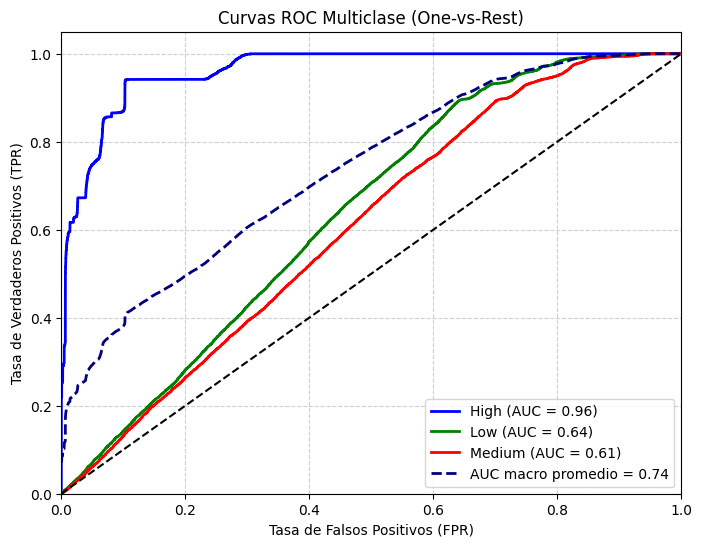


===== AUC por clase =====
High: 0.9619
Low: 0.6377
Medium: 0.6070
AUC macro promedio: 0.7355


({0: np.float64(0.9619091058667372),
  1: np.float64(0.6376813473799239),
  2: np.float64(0.6069629449902229)},
 np.float64(0.7355364597232114))

In [26]:
plot_roc_multiclass(model_cw,X_test,y_test)

El modelo muestra un excelente desempeño para la clase “High” (AUC = 0.9619), lo que indica una alta capacidad para identificar correctamente los casos de alto riesgo.
Sin embargo, las clases “Low” (0.6377) y “Medium” (0.6070) presentan un rendimiento moderado a bajo, reflejando cierta dificultad para distinguir entre niveles de riesgo menos severos.

El AUC macro promedio (0.735) confirma un rendimiento global aceptable, aunque con margen de mejora en la diferenciación de las clases minoritarias.

como podemos ver, en si no es que cambie mucho en comparacion a los anteriores

## Tabla comparativa

| LogisticRegression       | Accuracy | Precision_macro | Recall_macro | F1-macro | AUC  | Tiempo en minutos
|---------------|----------|----------|--------|----------|------|------|
| Benchmark      | 0.59     | 0.42     | 0.57   | 0.48     | 0.73 | 0.10
| SMOTE     | 0.51     | 0.53     | 0.61   | 0.55     | 0.74 | 0.23
| ADASYN     | 0.58    | 0.51     | 0.60   | 0.48     | 0.74 |0.36 
| class_weight     | 0.56     | 0.52     | 0.61   | 0.53     | 0.73 | 0.09

Entre los modelos de LogisticRegression realizados se pudo observar que SMOTE es el mejor de entre todos, teniendo un mejor balance entre todas las clases en general y tiene mayor recall a comparacion de los otros

### Gridsearch

realizamos gridsearch y tuning de hiperparametros con el mejor modelo de los vistos el cual es el de SMOTE

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [28]:
scoring = {
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

In [29]:
param_grid_log = {
    'model__C': [0.01, 0.1, 1, 10,100]
}

In [30]:
start = time.time()
grid_log_bal = gridsearch_pipeline(pipe_logit_bal, param_grid_log, X_train, y_train, cv=cv, scoring=scoring)
end = time.time()

In [31]:
print("Logistic GridSearch balanceado SMOTE - Mejor score:", grid_log_bal.best_score_)
print("Logistic GridSearch balanceado SMOTE - Params:", grid_log_bal.best_params_)
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Logistic GridSearch balanceado SMOTE - Mejor score: 0.6066070125494305
Logistic GridSearch balanceado SMOTE - Params: {'model__C': 0.01}
Tiempo de ejecución: 3.74 minutos


El modelo de Regresión Logística con balanceo mediante SMOTE alcanzó un mejor puntaje de 0.6066, utilizando un valor de regularización C = 0.01, lo que indica un modelo con mayor penalización y menor complejidad.

El resultado sugiere que el modelo logra un rendimiento moderado, siendo capaz de aprovechar parcialmente los datos sintéticos generados por SMOTE para mejorar el equilibrio entre clases, aunque aún hay margen para optimizar su capacidad predictiva.

El tiempo de ejecución (3.74 minutos) fue razonable, considerando la búsqueda de hiperparámetros y el proceso de sobremuestreo.

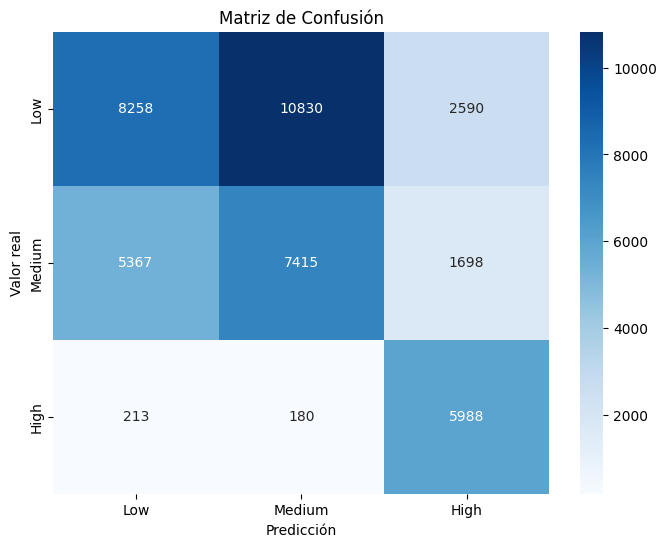


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.38      0.47     21678
      Medium       0.40      0.51      0.45     14480
        High       0.58      0.94      0.72      6381

    accuracy                           0.51     42539
   macro avg       0.53      0.61      0.54     42539
weighted avg       0.53      0.51      0.50     42539



{'Accuracy': 0.5092033193069889,
 'Precision (macro)': 0.527307294078184,
 'Recall (macro)': 0.6104785812579032,
 'F1-score (macro)': 0.5448994122184374,
 'ROC-AUC': np.float64(0.7354410852872407)}

In [32]:
evaluar_modelo(grid_log_bal.best_estimator_,X_test,y_test)

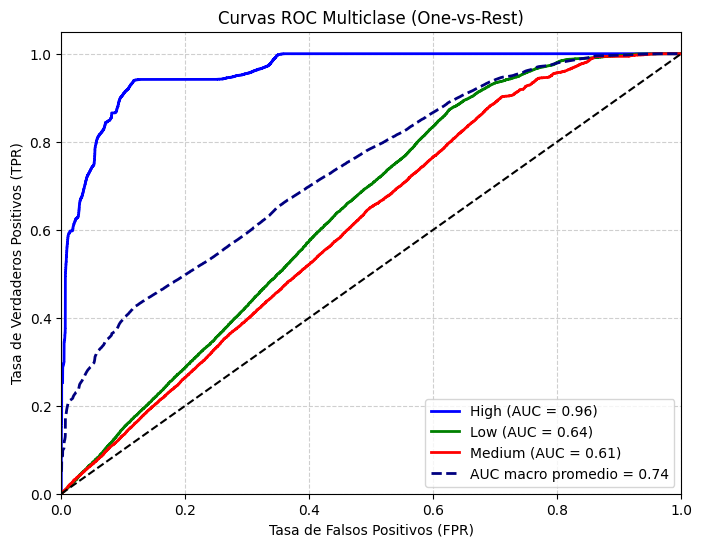


===== AUC por clase =====
High: 0.9590
Low: 0.6391
Medium: 0.6081
AUC macro promedio: 0.7355


({0: np.float64(0.9590422197501798),
  1: np.float64(0.6391353721505004),
  2: np.float64(0.6081456639610419)},
 np.float64(0.7354599685600501))

In [33]:
plot_roc_multiclass(grid_log_bal.best_estimator_,X_test,y_test)

Los valores de AUC indican el desempeño del modelo para distinguir correctamente cada categoría del riesgo de cáncer de tiroides:

Clase "High" (AUC = 0.9590): el modelo tiene excelente capacidad predictiva para identificar pacientes con alto riesgo.

Clase "Low" (AUC = 0.6391): el rendimiento es moderado, indicando cierta dificultad para separar correctamente los casos de bajo riesgo.

Clase "Medium" (AUC = 0.6081): el modelo presenta rendimiento limitado en la identificación de riesgos intermedios.

El AUC macro promedio (0.7355) sugiere un buen desempeño general, aunque el modelo muestra un desequilibrio en su capacidad de discriminación entre clases, siendo más preciso para el grupo de alto riesgo que para los demás.